# NB02 — Harmonised Hazard, Exposure, and Vulnerability Grids

This notebook is the harmonisation part of the URBADAPT workflow. It takes the raw climate, population, and vulnerability inputs from NB01 and translates them into a shared spatial framework: a common UrbClim `T2M` grid, a consistent city mask, age-structured population layers, and a vulnerability layer on the same geometry.

Concretely, NB02:
- builds daily mean `T2M` hazard files for the target years from historical UrbClim fields plus monthly climate deltas;
- defines the reference grid and shared spatial metadata used downstream;
- aggregates age-structured WorldPop rasters into the three age groups used in the framework and reprojects them conservatively to the hazard grid;
- scales the 2030 exposure to 2040 and 2050 with WCDE/Wittgenstein Centre age-specific growth factors by scenario;
- constructs the vulnerability layer on the same grid through `cityheat/vulnerability_layer.py`;
- saves manifests, masks, `.npz` arrays, and convenience GeoTIFFs for later notebooks.

A key modelling choice to remember is that the 2020 climate layer is synthetic: it is derived from the historical 2008-2017 UrbClim rather than from an observed 2020 daily series. Likewise, 2020 and 2030 population are direct WorldPop products, whereas 2040 and 2050 are scenario-scaled from the 2030 spatial distribution. NB02 therefore provides the harmonised hazard-exposure-vulnerability inputs that NB03 and the policy notebooks build on.

In [1]:
# Select the city run. WorldPop and WCDE country identifiers are read from the city config.
import os
os.environ["CITY"] = "Copenhagen"   # pick the city here


In [2]:
# Bootstrap the city-specific configuration and resolve the base, output, and interim paths.
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# `CITY` is the authoritative selector; the fallback on the next line is only a notebook-local default.
SLUG = globals().get("SLUG", os.environ.get("CITY", "Copenhagen")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")


→ City: Copenhagen  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/copenhagen  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/interim


In [3]:
# Select the climate-scenario column used when reading the monthly T2M deltas.
T2M_SCEN = "CurPol" # choosing scenario we want for the UrbClim deltas 


In [4]:
# Shortcut to the parsed city YAML configuration.
cfg  = C.get("cfg")     # dict loaded from YAML


In [5]:
# Resolve the climate-delta scenario, baseline construction mode, and across-GCM delta band.
clim_cfg = cfg.get("climate", {})

# Optional notebook override; otherwise the value comes from the config or environment.
T2M_SCEN_OVERRIDE = globals().get("T2M_SCEN_OVERRIDE", None)

T2M_SCEN = (
    str(T2M_SCEN_OVERRIDE).strip()
    if T2M_SCEN_OVERRIDE is not None
    else os.environ.get(
        "T2M_SCEN",
        clim_cfg.get("t2m_clim_scen_default", "CurPol") # CurPol by default
    )
)
options = clim_cfg.get("t2m_clim_scen_options", [])
if options and T2M_SCEN not in options:
    raise ValueError(f"T2M_SCEN={T2M_SCEN!r} not in allowed options: {options}")

print(f"→ Using climate deltas scenario: {T2M_SCEN}")

# Baseline construction mode for the synthetic 2020 hazard (also used in uncertainty runs).
# - climatology_mean: current default (daily climatological mean over 2008-2017)
# - pixelwise_doy_max: pixelwise day-of-year maxima over 2008-2017 (extreme sensitivity)
# - domain_peak_day: daily sequence from the year containing the hottest domain-mean day
# - warmest_summer: daily sequence from the year with highest JJA domain-mean temperature
T2M_BASELINE_MODE_OVERRIDE = globals().get("T2M_BASELINE_MODE_OVERRIDE", None)

T2M_BASELINE_MODE = (
    str(T2M_BASELINE_MODE_OVERRIDE).strip()
    if T2M_BASELINE_MODE_OVERRIDE is not None
    else os.environ.get(
        "T2M_BASELINE_MODE",
        clim_cfg.get("t2m_baseline_mode_default", "climatology_mean")
    )
)
T2M_BASELINE_MODE = str(T2M_BASELINE_MODE).strip().lower()
_mode_aliases = {
    "climatology": "climatology_mean",
    "average_year": "climatology_mean",
    "pixelwise_max": "pixelwise_doy_max",
    "extreme_pixelwise": "pixelwise_doy_max",
    "domain_max_day": "domain_peak_day",
    "extreme_event": "pixelwise_doy_max",
    "extreme_day": "domain_peak_day",
    "warmest_year": "warmest_summer",
    "hottest_summer": "warmest_summer",
}
T2M_BASELINE_MODE = _mode_aliases.get(T2M_BASELINE_MODE, T2M_BASELINE_MODE)
_ALLOWED_BASELINE_MODES = {"climatology_mean", "pixelwise_doy_max", "domain_peak_day", "warmest_summer"}
if T2M_BASELINE_MODE not in _ALLOWED_BASELINE_MODES:
    raise ValueError(
        f"T2M_BASELINE_MODE={T2M_BASELINE_MODE!r} not in allowed modes: {sorted(_ALLOWED_BASELINE_MODES)}"
    )
print(f"→ Using baseline mode: {T2M_BASELINE_MODE}")

# Delta band used for uncertainty runs.
# For tas/T2M, each model first contributes its avg(pct45,pct55) monthly delta.
# The low/central/high labels then refer to the across-GCM spread of those representative deltas.
T2M_PCT_BAND_OVERRIDE = globals().get("T2M_PCT_BAND_OVERRIDE", None)

T2M_PCT_BAND = (
    str(T2M_PCT_BAND_OVERRIDE).strip()
    if T2M_PCT_BAND_OVERRIDE is not None
    else os.environ.get(
        "T2M_PCT_BAND",
        clim_cfg.get("t2m_delta_pct_band_default", "central")
    )
)
T2M_PCT_BAND = str(T2M_PCT_BAND).strip().lower()
_ALLOWED_PCT_BANDS = {"low", "central", "high"}
if T2M_PCT_BAND not in _ALLOWED_PCT_BANDS:
    raise ValueError(
        f"T2M_PCT_BAND={T2M_PCT_BAND!r} not in allowed bands: {sorted(_ALLOWED_PCT_BANDS)}"
    )
print(f"→ Using delta percentile band: {T2M_PCT_BAND}")


→ Using climate deltas scenario: CurPol
→ Using baseline mode: climatology_mean
→ Using delta percentile band: central


In [6]:
# Verify that the core inputs needed for hazard, exposure, and vulnerability harmonisation are available.
required = [
    P(cfg["files"]["gvi_csv"]),
    P("fua"),
]

# Create the local folder used for downloaded WorldPop rasters if it does not exist yet.
worldpop_dir = BASE / "worldpop"
worldpop_dir.mkdir(parents=True, exist_ok=True)

missing = [p for p in required if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "Some inputs are missing. Run Notebook 1 (Drive sync) first:\n" +
        "\n".join(str(p) for p in missing)
    )


In [7]:
import geopandas as gpd

# Load the city Functional Urban Area from the city-specific input folder.
p_FUA = P("fua")
candidates = sorted(p_FUA.glob("*.geojson")) + sorted(p_FUA.glob("*.gpkg")) + sorted(p_FUA.glob("*.shp"))
candidates = [p for p in candidates if SLUG in p.stem.lower()] or candidates
assert candidates, f"No FUA file found in {p_FUA}"
fua_path = candidates[0]

fua = gpd.read_file(fua_path)
if fua.empty:
    raise ValueError("Loaded FUA is empty.")


## Climate Hazard Fields on the UrbClim Grid


The first block of the notebook turns historical and projected temperature information into daily hazard files on a common grid. The workflow combines a synthetic baseline calendar with monthly climate deltas, masks the result to the Functional Urban Area, and records the scenario choices that generated each run.


By construction, the 2020 layer is not an observed 2020 time series. It is a synthetic baseline derived from the historical 2008-2017 UrbClim archive. The default baseline uses the month/day climatological mean, but the code also supports alternative baseline constructions (`pixelwise_doy_max`, `domain_peak_day`, `warmest_summer`) and low/central/high climate-delta bands for sensitivity and uncertainty analysis.

For `tas` / `T2M`, these bands are **not** within-model warming percentiles. The workflow first assigns each climate model a representative monthly delta equal to the average of `pct45` and `pct55`, which is treated as the model's central warming estimate. The notebook then uses the across-model spread of those representative deltas to define the `low`, `central`, and `high` bands (respectively the 25th, 50th, and 75th percentiles across GCMs). When the band-aware delta table exists, it is read directly; otherwise the notebook falls back to the legacy central-average table.


In [8]:
# Build annual daily-mean T2M hazard files on the UrbClim grid and save them masked to the FUA.
import os
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr
import geopandas as gpd
from affine import Affine
import rasterio.features as rfeat
from rasterio.crs import CRS

# Historical 2008-2017 daily-mean T2M archive on the native UrbClim grid.

t2m_dir   = P("UrbClim/UrbClimT2Mmean")
t2m_files = sorted(t2m_dir.glob("T2M_year_daily_mean_*.nc"))
assert t2m_files, "No T2M_year_daily_mean_*.nc files found."

ds = xr.open_mfdataset(t2m_files, combine="by_coords", decode_times=True)
vname = next((v for v in ("T2M","t2m","tas","temperature") if v in ds.data_vars), list(ds.data_vars)[0])
daK = ds[vname]  # (time,y,x), K

def _build_month_day_template_K(da_histK: xr.DataArray) -> xr.DataArray:
    md = da_histK.groupby("time.month").map(lambda grp: grp.groupby("time.day").mean("time"))
    return md.reindex(day=np.arange(1, 32)).ffill("day")

def build_baseline_calendar_K(da_histK: xr.DataArray, mode: str):
    mode = str(mode).strip().lower()

    if mode == "climatology_mean":
        md = _build_month_day_template_K(da_histK)
        meta = {
            "baseline_mode": mode,
            "baseline_label": "2008-2017 month/day climatological mean",
            "extreme_peak_day": None,
        }
        return md, meta

    if mode == "pixelwise_doy_max":
        md = da_histK.groupby("time.month").map(lambda grp: grp.groupby("time.day").max("time"))
        md = md.reindex(day=np.arange(1, 32)).ffill("day")
        meta = {
            "baseline_mode": mode,
            "baseline_label": "2008-2017 pixelwise month/day maxima",
            "extreme_peak_day": None,
        }
        return md, meta

    if mode == "domain_peak_day":
        domain_mean = da_histK.mean(dim=("y", "x"), skipna=True)
        peak_idx = int(domain_mean.argmax(dim="time").values)
        peak_time = pd.to_datetime(domain_mean["time"].values[peak_idx])
        peak_year = int(peak_time.year)
        year_series = da_histK.sel(time=(da_histK["time.year"] == peak_year))
        if int(year_series.sizes.get("time", 0)) == 0:
            raise ValueError(f"Could not extract baseline year {peak_year} from historical T2M series")
        md = year_series.groupby("time.month").map(lambda grp: grp.groupby("time.day").max("time"))
        md = md.reindex(day=np.arange(1, 32)).ffill("day")
        meta = {
            "baseline_mode": mode,
            "baseline_label": f"daily sequence from year of hottest domain-mean day ({peak_year})",
            "extreme_peak_day": str(peak_time.date()),
            "extreme_peak_year": peak_year,
        }
        return md, meta

    if mode == "warmest_summer":
        # Find the year with the highest JJA domain-mean temperature
        domain_mean = da_histK.mean(dim=("y", "x"), skipna=True)
        jja = domain_mean.sel(time=domain_mean["time.month"].isin([6, 7, 8]))
        jja_annual = jja.groupby("time.year").mean("time")
        warmest_year = int(jja_annual.idxmax(dim="year").values)
        year_series = da_histK.sel(time=(da_histK["time.year"] == warmest_year))
        if int(year_series.sizes.get("time", 0)) == 0:
            raise ValueError(f"Could not extract baseline year {warmest_year} from historical T2M series")
        # Use actual daily values from that year (single year → groupby is identity)
        md = year_series.groupby("time.month").map(lambda grp: grp.groupby("time.day").mean("time"))
        md = md.reindex(day=np.arange(1, 32)).ffill("day")
        jja_mean_C = float(jja_annual.sel(year=warmest_year).values) - 273.15
        meta = {
            "baseline_mode": mode,
            "baseline_label": f"daily sequence from warmest summer year ({warmest_year}, JJA mean {jja_mean_C:.1f}°C)",
            "extreme_peak_day": None,
            "extreme_peak_year": warmest_year,
            "jja_domain_mean_C": jja_mean_C,
        }
        return md, meta

    raise ValueError(f"Unsupported baseline mode: {mode}")

md_clim, baseline_meta = build_baseline_calendar_K(daK, T2M_BASELINE_MODE)
if baseline_meta.get("extreme_peak_day"):
    print(f"→ Domain peak day used for baseline sensitivity: {baseline_meta['extreme_peak_day']}")
if baseline_meta.get("extreme_peak_year"):
    print(f"→ Baseline year selected: {baseline_meta['extreme_peak_year']}")
print(f"→ Baseline construction: {baseline_meta['baseline_label']}")

# Keep the grid axes after closing the multi-file dataset.
x = md_clim["x"].values
y = md_clim["y"].values

ds.close()

# Monthly delta table used to perturb the historical baseline.
# The band-aware CSV stores low/central/high as across-GCM bands built from model-level tas deltas.
# For tas/T2M, each model-level delta is the average of pct45 and pct55 before the across-model bands are computed.
# The legacy avg CSV only preserves that central representative delta, so it is equivalent to the central band.
import pandas as pd

bands_table_path = BASE / "T2MmeanDeltas/climate_change_provide_markups_bands.csv"
legacy_table_path = P(cfg["files"]["t2m_deltas_table"])

if bands_table_path.exists():
    df_deltas_all = pd.read_csv(bands_table_path)
    # Filter to the selected across-GCM delta band.
    df_deltas = df_deltas_all[df_deltas_all["pct_band"] == T2M_PCT_BAND].copy()
    if df_deltas.empty:
        raise ValueError(
            f"No deltas found for pct_band={T2M_PCT_BAND!r} in {bands_table_path}. "
            f"Available bands: {sorted(df_deltas_all['pct_band'].unique())}"
        )
    deltas_table_path = bands_table_path
    print(f"→ Using band-aware deltas: {bands_table_path} (band={T2M_PCT_BAND})")
else:
    df_deltas = pd.read_csv(legacy_table_path)
    deltas_table_path = legacy_table_path
    if T2M_PCT_BAND != "central":
        print(f"⚠ Band CSV not found at {bands_table_path}; falling back to legacy avg CSV (central only).")
        print(f"  Run: python scripts/build_delta_bands.py to generate band CSV.")
    else:
        print(f"→ Using legacy deltas: {legacy_table_path} (central band)")

# Target years come from the climate config, with AC years kept as a compatibility fallback.
wanted_years = clim_cfg.get("years", cfg.get("ac", {}).get("years", [2020, 2030, 2040, 2050]))
wanted_years = list(wanted_years)

# Match delta-table city names using the aliases declared in the config.
city_aliases = cfg.get("cooling_city_aliases") or [
    cfg.get("city_name", CITY),
    CITY,
    SLUG,
    SLUG.capitalize(),
]
city_aliases_low = [c.lower() for c in city_aliases]

t2m_var = clim_cfg.get("t2m_var", "tas")

def read_monthly_delta_C(year: int) -> np.ndarray:
    """Return 12-element array (Jan..Dec) of deltas in °C for given year + scenario."""
    
    # The synthetic 2020 hazard uses the baseline calendar with zero added warming.
    if year <= 2020:
        return np.zeros(12)
    
    # Future years read their monthly deltas from the selected table.
    df = df_deltas.copy()
    df["city_low"] = df["city"].str.lower()

    sub = df[
        df["city_low"].isin(city_aliases_low)
        & (df["year"] == year)
        & (df["clim_scen"] == T2M_SCEN)
        & (df["var"] == t2m_var)
    ]

    if sub.empty:
        raise ValueError(
            f"No climate deltas found in {deltas_table_path} for "
            f"city={city_aliases} year={year} scen={T2M_SCEN} var={t2m_var}"
        )

    # Expect one row per month, with month encoded as 1..12.
    sub = sub.sort_values("month")
    if sub["month"].nunique() != 12:
        raise ValueError(
            f"Expected 12 months of deltas for year={year}, scen={T2M_SCEN}, "
            f"got {sub['month'].nunique()}"
        )

    deltas = (
        sub.set_index("month")
           .loc[range(1, 13), "delta"]
           .astype(float)
           .to_numpy()
    )
    return deltas

for yr in wanted_years:
    dmC = read_monthly_delta_C(yr)
    print(f"ΔT (scenario={T2M_SCEN}, band={T2M_PCT_BAND}) for {yr}: {dmC}")

# Build a full daily series by adding the month-specific deltas to the baseline calendar.
def build_future_daily(yr: int, md_baseK: xr.DataArray, month_deltaC: np.ndarray) -> xr.DataArray:
    times = pd.date_range(f"{yr}-01-01", f"{yr}-12-31", freq="D")
    months = []
    for m in range(1, 13):
        ndays = int((times.month == m).sum())
        base_md = md_baseK.sel(month=m).isel(day=slice(0, ndays))
        fut_md  = base_md + float(month_deltaC[m-1])  # add °C to K (same increment)
        months.append(fut_md)
    futK = xr.concat(months, dim="day").rename({"day":"time"}).assign_coords(time=times)
    futK.name = "T2M"
    return futK.assign_attrs(units="K")

# Build the FUA mask on the same UrbClim (x, y) grid in EPSG:3035.
p_FUA = P("fua")
fua_path = (sorted(p_FUA.glob("*.geojson")) + sorted(p_FUA.glob("*.gpkg")) + sorted(p_FUA.glob("*.shp")))[0]
fua = gpd.read_file(fua_path).to_crs(CRS.from_epsg(3035))

dx = float(abs(np.diff(x).mean()))
dy = float(abs(np.diff(y).mean()))
transform = Affine.translation(float(x.min()) - dx/2,
                               float(y.max()) + dy/2) * Affine.scale(dx, -dy)

fua_mask = rfeat.geometry_mask(
    [g for g in fua.geometry if g is not None],
    out_shape=(len(y), len(x)),
    transform=transform,
    invert=True
)
fua_mask_da = xr.DataArray(fua_mask, coords={"y": y, "x": x}, dims=("y", "x"))

# Write NetCDFs defensively to avoid partial files or sync-related overwrite issues.
def robust_save(da: xr.DataArray, out_nc: Path):
    out_nc = str(out_nc)
    if os.path.exists(out_nc):
        try:
            os.chmod(out_nc, 0o644)
            os.remove(out_nc)
        except Exception as e:
            raise RuntimeError(f"Close any app using {out_nc} and retry. ({e})")
    tmp = out_nc + ".tmp"
    try:
        da.to_dataset(name=da.name or "T2M").to_netcdf(tmp, mode="w", engine="netcdf4")
        os.replace(tmp, out_nc)
    except Exception:
        try:
            if os.path.exists(tmp): os.remove(tmp)
        except Exception:
            pass
        da.to_dataset(name=da.name or "T2M").to_netcdf(tmp, mode="w", engine="scipy")
        os.replace(tmp, out_nc)

# Encode the baseline mode, climate scenario, and delta band in a run tag for bookkeeping.
def _slugify_part(x) -> str:
    return "".join(ch.lower() if ch.isalnum() else "-" for ch in str(x).strip()).strip("-")

T2M_RUN_TAG = (
    f"bm-{_slugify_part(T2M_BASELINE_MODE)}"
    f"__sc-{_slugify_part(T2M_SCEN)}"
    f"__pb-{_slugify_part(T2M_PCT_BAND)}"
)
print(f"→ Hazard run tag: {T2M_RUN_TAG}")

def hazard_nc_path(year: int, tagged: bool = True) -> Path:
    stem = f"T2M_daily_mean_{int(year)}_FUA_degC"
    if tagged:
        stem = f"{stem}__{T2M_RUN_TAG}"
    return OUTP(f"hazard/{stem}.nc")

# Build, mask, and save one annual T2M file per target year.
zeros = np.zeros(12)
for year in wanted_years:
    dmC = read_monthly_delta_C(year)   # uses the selected scenario and across-GCM band

    futK = build_future_daily(year, md_clim, dmC)
    futC = (futK.where(fua_mask_da) - 273.15).astype("float32")
    futC.name = "T2M"
    futC = futC.assign_attrs(units="degC", source_units="K")

    baseK_samecal = build_future_daily(year, md_clim, zeros)
    baseC_samecal = (baseK_samecal.where(fua_mask_da) - 273.15)

    base_monthC = baseC_samecal.groupby("time.month").mean(("time","y","x")).values
    fut_monthC  = futC.groupby("time.month").mean(("time","y","x")).values

    print(f"\n{year} ({T2M_SCEN}; baseline={T2M_BASELINE_MODE}; band={T2M_PCT_BAND}) city-mean monthly (°C) — base(same cal) | delta | future")
    for m in range(12):
        print(f"{m+1:02d}: {base_monthC[m]:6.2f} | {dmC[m]:+6.2f} | {fut_monthC[m]:6.2f}")

    out_nc_tagged = hazard_nc_path(year, tagged=True)
    out_nc_legacy = hazard_nc_path(year, tagged=False)

    robust_save(futC, out_nc_tagged)
    robust_save(futC, out_nc_legacy)

    print(f"Saved {out_nc_tagged}")
    print(f"Saved {out_nc_legacy} (compat)")


→ Baseline construction: 2008-2017 month/day climatological mean
→ Using legacy deltas: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/copenhagen/T2MmeanDeltas/climate_change_provide_markups_avg.csv (central band)
ΔT (scenario=CurPol, band=central) for 2020: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
ΔT (scenario=CurPol, band=central) for 2030: [0.41500462 0.58079887 0.25218301 0.35195068 0.28119657 0.23607164
 0.33281795 0.38001907 0.32933831 0.26218994 0.19140921 0.23352363]
ΔT (scenario=CurPol, band=central) for 2040: [0.73231347 0.5955052  0.56729018 0.52372494 0.48034909 0.41913458
 0.5774493  0.65084192 0.42542678 0.45026897 0.57972785 0.85867894]
ΔT (scenario=CurPol, band=central) for 2050: [1.16079884 0.8422993  0.73845152 0.82941589 0.6394574  0.82549558
 0.78367028 0.97318634 0.86518908 0.50892036 0.64125795 0.92363271]
→ Hazard run tag: bm-climatology-mean__sc-curpol__pb-central

2020 (CurPol; baseline=climatology_mean; band=central) city-mean monthly (°C) — ba

## Reference Grid and Shared Geometry

Once the annual `T2M` files are written, the notebook adopts that UrbClim geometry as the common spatial reference used by every downstream layer. The metadata extracted here (`crs`, `transform`, `height`, `width`) are later reused for population reprojection, vulnerability construction, and output writing. The final city analysis mask is completed after population has been brought onto this grid.


In [9]:
# Recover the common reference grid from one of the saved T2M hazard files.
# All yearly T2M outputs share the same UrbClim geometry, so a single slice is enough.
import xarray as xr
from affine import Affine
from rasterio.crs import CRS

# Use any saved T2M output; the 2030 file is convenient and grid-identical to the others.
t2m_ref_nc = OUTP("hazard/T2M_daily_mean_2030_FUA_degC.nc")
ds_ref = xr.open_dataset(t2m_ref_nc)
da_ref = ds_ref["T2M"].isel(time=0)      # 2D slice on the UrbClim grid

x = da_ref["x"].values
y = da_ref["y"].values
dx = float(abs(np.diff(x).mean()))
dy = float(abs(np.diff(y).mean()))

ref_transform = Affine.translation(float(x.min()) - dx/2,
                                   float(y.max()) + dy/2) * Affine.scale(dx, -dy)

ref_crs       = CRS.from_epsg(3035)      # UrbClim T2M is on LAEA Europe
ref_shape     = (da_ref.sizes["y"], da_ref.sizes["x"])

ref_meta = {
    "crs": ref_crs,
    "transform": ref_transform,
    "height": ref_shape[0],
    "width":  ref_shape[1],
    "dtype": "float32",
}

ref_data = da_ref.values   # NaNs outside the FUA after masking


## Population Exposure on the Reference Grid

Exposure is built from age-structured WorldPop rasters. The notebook first prepares direct 2020 and 2030 grids on the native WorldPop geometry, aggregates them into the three age groups used downstream (`<15`, `15-64`, `65+`), and then reprojects them to the UrbClim reference grid with conservative summation so that people are preserved when moving between grids.


In [10]:
# Helper to read a raster, reproject the FUA, and crop/mask it to the study area.
import numpy as np
import rasterio as rio
from rasterio.mask import mask as rio_mask

def read_and_mask_to_fua(raster_path, fua_gdf):
    with rio.open(raster_path) as src:
        src_crs = src.crs
        fua_in_src = fua_gdf.to_crs(src_crs)
        geoms = [g for g in fua_in_src.geometry if g is not None]
        if not geoms:
            raise ValueError("FUA geometry is empty/invalid.")
        out, out_transform = rio_mask(
            src, geoms, crop=True, filled=True, nodata=np.nan
        )
        meta = src.meta.copy()
        meta.update(height=out.shape[1], width=out.shape[2], transform=out_transform)
        data = out[0].astype(float)
    return data, out_transform, src_crs, meta


In [11]:
# WorldPop download helpers: fetch age-structured rasters for the selected country and years.


In [12]:
# Parameters for the WorldPop age-structure download and the broad age groups used downstream.
WP_ISO3 = str(cfg.get("wp_iso3", os.environ.get("WP_ISO3", ""))).upper()   # e.g. ITA, DNK, ESP
WP_COUNTRY = str(cfg.get("wp_country", os.environ.get("WP_COUNTRY", "")))   # needed later for Witt cell
WP_YEARS = [2020, 2030]

WP_RELEASE = "R2025A"
WP_VERSION = "v1"
WP_RESOLUTION = "100m"
WP_TYPE = "CN"
WP_GENDER = "t"   # total population only; sex-specific splits are not used in this notebook

WP_AGE_CODES = ["00", "01"] + [f"{a:02d}" for a in range(5, 90, 5)] + ["90"]

AGE_GROUPS = {
    "<15":   ["00", "01", "05", "10"],
    "15-64": ["15", "20", "25", "30", "35", "40", "45", "50", "55", "60"],
    "65+":   ["65", "70", "75", "80", "85", "90"],
}
ALL_CODES = [c for codes in AGE_GROUPS.values() for c in codes]


In [13]:
import requests
from pathlib import Path
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

WP_API = "https://hub.worldpop.org/rest/data/age_structures"  # WorldPop age-structure endpoint
WP_PRODUCT_ALIAS = "G2_CN_Age_R25A_100m"  # 100 m constrained product alias

WP_BASES = [
    "https://worldpop-public-data.soton.ac.uk/GIS/AgeSex_structures/Global_2015_2030",
    "https://data.worldpop.org/GIS/AgeSex_structures/Global_2015_2030",
]

# Sanity check: confirm that the expected product alias exists in the live API.
r = requests.get(WP_API, timeout=60)
r.raise_for_status()
aliases = {d["alias"] for d in r.json()["data"]}
assert WP_PRODUCT_ALIAS in aliases, f"{WP_PRODUCT_ALIAS} not found in WorldPop API"

def wp_filename(iso3, year, age_code, gender=WP_GENDER,
                release=WP_RELEASE, version=WP_VERSION,
                resolution=WP_RESOLUTION, kind=WP_TYPE):
    return f"{iso3.lower()}_{gender}_{age_code}_{year}_{kind}_{resolution}_{release}_{version}.tif"

def wp_candidate_urls(iso3, year, age_code, gender=WP_GENDER):
    fname = wp_filename(iso3, year, age_code, gender)
    iso3 = iso3.upper()
    return [
        f"{base}/{WP_RELEASE}/{year}/{iso3}/{WP_VERSION}/{WP_RESOLUTION}/constrained/{fname}"
        for base in WP_BASES
    ]

def make_session():
    session = requests.Session()
    retry = Retry(
        total=5,
        connect=5,
        read=5,
        backoff_factor=2,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    adapter = HTTPAdapter(max_retries=retry)
    session.mount("http://", adapter)
    session.mount("https://", adapter)
    return session

def download_worldpop_file(iso3, year, age_code, dest_dir, gender=WP_GENDER, overwrite=False):
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)

    fname = wp_filename(iso3, year, age_code, gender)
    dest = dest_dir / fname

    if dest.exists() and dest.stat().st_size > 0 and not overwrite:
        return dest

    errors = []
    session = make_session()

    for url in wp_candidate_urls(iso3, year, age_code, gender):
        tmp = dest.with_suffix(dest.suffix + ".part")
        try:
            print(f"Trying: {url}")
            with session.get(url, stream=True, timeout=(30, 600)) as resp:
                resp.raise_for_status()

                with open(tmp, "wb") as f:
                    for chunk in resp.iter_content(chunk_size=1024 * 1024):
                        if chunk:
                            f.write(chunk)

                tmp.replace(dest)
                return dest

        except requests.exceptions.RequestException as e:
            errors.append(f"{url} -> {type(e).__name__}: {e}")
            if tmp.exists():
                tmp.unlink()

    raise FileNotFoundError(
        f"Could not download {fname}\n" + "\n".join(errors)
    )

def ensure_worldpop_country_year(iso3, year, age_codes=ALL_CODES, gender=WP_GENDER):
    local_dir = P("worldpop") / iso3.upper() / str(year)
    paths = []
    for code in age_codes:
        paths.append(download_worldpop_file(iso3, year, code, local_dir, gender=gender))
    return paths

# Download only the total-population age bands needed for the 2020 and 2030 runs.
for yr in WP_YEARS:
    _ = ensure_worldpop_country_year(WP_ISO3, yr, age_codes=ALL_CODES, gender=WP_GENDER)

print(f"WorldPop files ready for {WP_ISO3}: {WP_YEARS}")


WorldPop files ready for DNK: [2020, 2030]


In [14]:
# Resolve downloaded WorldPop files and aggregate detailed age bands into the three modelled groups.
def worldpop_age_path(code, year, iso3=WP_ISO3, gender=WP_GENDER):
    fname = wp_filename(iso3, year, code, gender)
    folder = P("worldpop") / iso3.upper() / str(year)
    path = folder / fname

    if not path.exists():
        ensure_worldpop_country_year(iso3, year, age_codes=[code], gender=gender)

    if not path.exists():
        raise FileNotFoundError(f"Missing WorldPop file: {path}")

    return path

def build_age_group_rasters(fua_gdf, year, iso3=WP_ISO3, gender=WP_GENDER):
    agg = {"<15": None, "15-64": None, "65+": None}
    wp_meta = None

    for code in ALL_CODES:
        arr, _, _, meta = read_and_mask_to_fua(worldpop_age_path(code, year, iso3, gender), fua_gdf)
        arr = np.nan_to_num(arr, nan=0.0).astype(np.float32)

        if wp_meta is None:
            wp_meta = meta

        for grp, codes in AGE_GROUPS.items():
            if code in codes:
                agg[grp] = arr if agg[grp] is None else (agg[grp] + arr)
                break

    # Fill any missing aggregate group with zeros so the downstream structure is always complete.
    template = next(v for v in agg.values() if v is not None)
    for k, v in agg.items():
        if v is None:
            agg[k] = np.zeros_like(template, dtype=np.float32)

    return agg, wp_meta


In [15]:
# Build direct 2020 and 2030 age-group exposure grids and reproject them to the T2M reference grid.

from rasterio.warp import reproject
from rasterio.enums import Resampling
import numpy as np
import rasterio as rio
import geopandas as gpd

def worldpop_age_path(code, year, iso3=WP_ISO3, gender=WP_GENDER):
    fname = wp_filename(iso3, year, code, gender)
    folder = P("worldpop") / iso3.upper() / str(year)
    path = folder / fname

    if not path.exists():
        ensure_worldpop_country_year(iso3, year, age_codes=[code], gender=gender)

    if not path.exists():
        raise FileNotFoundError(f"Missing WorldPop file: {path}")

    return path

def build_age_group_rasters(fua_gdf, year, iso3=WP_ISO3, gender=WP_GENDER):
    agg = {"<15": None, "15-64": None, "65+": None}
    wp_meta = None

    for code in ALL_CODES:
        arr, _, _, meta = read_and_mask_to_fua(worldpop_age_path(code, year, iso3, gender), fua_gdf)
        arr = np.nan_to_num(arr, nan=0.0).astype(np.float32)

        if wp_meta is None:
            wp_meta = meta

        for grp, codes in AGE_GROUPS.items():
            if code in codes:
                agg[grp] = arr if agg[grp] is None else (agg[grp] + arr)
                break

    template = next(v for v in agg.values() if v is not None)
    for k, v in agg.items():
        if v is None:
            agg[k] = np.zeros_like(template, dtype=np.float32)

    return agg, wp_meta

def reproject_sum_to_ref(src_arr, src_meta, ref_meta, ref_like):
    out = np.zeros_like(ref_like, dtype=float)
    reproject(
        source=np.nan_to_num(src_arr, nan=0.0),
        destination=out,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"],
        dst_crs=ref_meta["crs"],
        resampling=Resampling.sum,
        src_nodata=0.0,
        dst_nodata=0.0,
    )
    return np.where(np.isfinite(ref_like), out, 0.0)

# Direct WorldPop exposure for 2020.
age_native, wp_meta = build_age_group_rasters(fua, year=2020, iso3=WP_ISO3)

print("Native-grid totals within FUA (people), 2020:")
for k, v in age_native.items():
    print(f"  {k:>5}: {float(v.sum()):,.0f}")

pop_native = sum(np.nan_to_num(v, nan=0.0) for v in age_native.values())
pop_on_ref = reproject_sum_to_ref(pop_native, wp_meta, ref_meta, ref_data)

age_on_ref = {
    grp: reproject_sum_to_ref(arr, wp_meta, ref_meta, ref_data)
    for grp, arr in age_native.items()
}

native_total = float(pop_native.sum())
ref_total = float(pop_on_ref.sum())
print("\nPopulation totals (people), 2020:")
print(f"  WP-native sum over FUA : {native_total:,.0f}")
print(f"  T2M-grid sum (reproj)  : {ref_total:,.0f}")

# Direct WorldPop exposure for 2030.
age_native_2030, wp_meta_2030 = build_age_group_rasters(fua, year=2030, iso3=WP_ISO3)

print("\nNative-grid totals within FUA (people), 2030:")
for k, v in age_native_2030.items():
    print(f"  {k:>5}: {float(v.sum()):,.0f}")

pop_native_2030 = sum(np.nan_to_num(v, nan=0.0) for v in age_native_2030.values())
pop_on_ref_2030 = reproject_sum_to_ref(pop_native_2030, wp_meta_2030, ref_meta, ref_data)

age_on_ref_2030 = {
    grp: reproject_sum_to_ref(arr, wp_meta_2030, ref_meta, ref_data)
    for grp, arr in age_native_2030.items()
}

native_total_2030 = float(pop_native_2030.sum())
ref_total_2030 = float(pop_on_ref_2030.sum())
print("\nPopulation totals (people), 2030:")
print(f"  WP-native sum over FUA : {native_total_2030:,.0f}")
print(f"  T2M-grid sum (reproj)  : {ref_total_2030:,.0f}")


Native-grid totals within FUA (people), 2020:
    <15: 354,942
  15-64: 1,397,532
    65+: 354,692

Population totals (people), 2020:
  WP-native sum over FUA : 2,107,166
  T2M-grid sum (reproj)  : 1,128,812

Native-grid totals within FUA (people), 2030:
    <15: 350,023
  15-64: 1,425,768
    65+: 423,231

Population totals (people), 2030:
  WP-native sum over FUA : 2,199,022
  T2M-grid sum (reproj)  : 1,178,069


In [16]:
assert pop_on_ref.shape == (ref_meta["height"], ref_meta["width"]), "Pop grid != ref grid shape"
for k, a in age_on_ref.items():
    assert a.shape == pop_on_ref.shape, f"Age band {k} shape != ref grid"

In [17]:
# Build the core analysis mask from valid hazard pixels with non-zero 2020 population.
CITY_MASK = np.isfinite(ref_data) & (pop_on_ref > 0) # main analysis mask         

# Check that the age groups sum back to the total population on the reference grid.
pop_from_ages = np.zeros_like(pop_on_ref, dtype=float)
for a in age_on_ref.values():
    pop_from_ages += np.nan_to_num(a)

abs_diff = float(np.abs(np.nansum(pop_from_ages) - np.nansum(pop_on_ref)))
rel_diff = abs_diff / max(np.nansum(pop_on_ref), 1.0)

print("\nSanity check — totals on T2M grid (people):")
for k, v in age_on_ref.items():
    print(f"  {k:>5}: {float(np.nansum(v)):.0f}")
print(f"  Sum(age bands): {float(np.nansum(pop_from_ages)):.0f}")
print(f"  pop_on_ref    : {float(np.nansum(pop_on_ref)):.0f}")
print(f"  Abs diff      : {abs_diff:.3f}  ({100*rel_diff:.4f}%)")



Sanity check — totals on T2M grid (people):
    <15: 182121
  15-64: 791915
    65+: 154776
  Sum(age bands): 1128812
  pop_on_ref    : 1128812
  Abs diff      : 0.000  (0.0000%)


## Future Population Scaling with WCDE

Direct gridded WorldPop inputs are available here for 2020 and 2030. For 2040 and 2050, the notebook keeps the 2030 spatial pattern as the high-resolution anchor and applies age-specific national growth factors from the Wittgenstein Centre / WCDE projections. This makes future exposure scenario-aware without inventing unsupported fine-scale redistribution within the city.


The WCDE pull is done on the fly for the selected country through the R `wcde` package, saved to the interim folder, and then harmonised from 5-year age bands to the same three broad age groups used in the framework. The resulting scenario labels and growth factors are written out so they can be reused downstream and tracked in uncertainty analysis.


In [18]:
# Download country-level WCDE projections used to scale 2030 population to 2040 and 2050.
import subprocess, textwrap, pandas as pd, numpy as np, json

# WCDE download for this country
WCDE_COUNTRY = WP_COUNTRY          # e.g. "Denmark", "Italy", "Spain"
WCDE_SCENARIOS = [1, 2, 3, 4, 5, 22, 23]
WCDE_YEARS = [2030, 2040, 2050]

wcde_csv = INT / f"wcde_pop_{WP_ISO3.lower()}.csv"

r_code = f"""
if (!requireNamespace("wcde", quietly = TRUE)) {{
  install.packages("wcde", repos = "https://cloud.r-project.org")
}}
if (!requireNamespace("dplyr", quietly = TRUE)) {{
  install.packages("dplyr", repos = "https://cloud.r-project.org")
}}
if (!requireNamespace("readr", quietly = TRUE)) {{
  install.packages("readr", repos = "https://cloud.r-project.org")
}}

library(wcde)
library(dplyr)
library(readr)

d <- get_wcde(
  indicator = "pop",
  scenario = c({",".join(map(str, WCDE_SCENARIOS))}),
  country_name = "{WCDE_COUNTRY}",
  pop_age = "all",
  pop_sex = "total",
  include_scenario_names = TRUE,
  server = "search-available",
  version = "wcde-v3"
) |>
  filter(year %in% c({",".join(map(str, WCDE_YEARS))}))

readr::write_csv(d, "{wcde_csv.as_posix()}")
"""

subprocess.run(["Rscript", "-e", r_code], check=True)
wic = pd.read_csv(wcde_csv)

print(f"Saved WCDE pull to {wcde_csv}")
print(wic.head())


Suggested citation for data:
Wittgenstein Centre for Demography and Global Human Capital (WIC) Wittgenstein Centre Data Explorer. Version 3.0 (Beta), 2023

Attachement du package : ‘dplyr’

Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag

Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union



Saved WCDE pull to /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/interim/wcde_pop_dnk.csv
   scenario             scenario_name scenario_abb     name  country_code  \
0         1  Rapid Development (SSP1)         SSP1  Denmark           208   
1         1  Rapid Development (SSP1)         SSP1  Denmark           208   
2         1  Rapid Development (SSP1)         SSP1  Denmark           208   
3         1  Rapid Development (SSP1)         SSP1  Denmark           208   
4         1  Rapid Development (SSP1)         SSP1  Denmark           208   

      age  year    pop  
0    0--4  2030  306.5  
1    5--9  2030  302.0  
2  10--14  2030  311.1  
3  15--19  2030  311.5  
4  20--24  2030  349.2  


In [19]:
# Build future age-specific population grids from WCDE growth factors.
# 2020: direct WorldPop 2020 grid on the reference geometry
# 2030: direct WorldPop 2030 grid on the reference geometry
# 2040 and 2050: scale the 2030 grid with age-specific WCDE growth factors

# Map WCDE 5-year ages to the three broad age groups used in the framework.
lt15   = ["0--4", "5--9", "10--14"]
a15_64 = ["15--19", "20--24", "25--29", "30--34", "35--39", "40--44",
          "45--49", "50--54", "55--59", "60--64"]
g65    = ["65--69", "70--74", "75--79", "80--84", "85--89",
          "90--94", "95--99", "100+"]

AGE_MAP = {a: "<15" for a in lt15}
AGE_MAP.update({a: "15-64" for a in a15_64})
AGE_MAP.update({a: "65+" for a in g65})

AGE_KEYS = ["<15", "15-64", "65+"]
YEARS_TARGET = (2020, 2030, 2040, 2050)
SCALE_BASE_YEAR = 2030

# Be tolerant to minor naming differences across WCDE versions
wic = wic.rename(columns={
    "name": "country_name",
    "scenario_abb": "scenario_code",
    "scenario_name": "scenario_name_full",
    "pop": "pop_k",
    "age": "age"
})

if "scenario_code" not in wic.columns:
    # fallback if scenario abbreviations are not returned
    code_map = {
        1: "SSP1", 2: "SSP2", 3: "SSP3", 4: "SSP4", 5: "SSP5",
        22: "SSP2-ZM", 23: "SSP2-DM"
    }
    wic["scenario_code"] = wic["scenario"].map(code_map)

wic["big_age"] = wic["age"].map(AGE_MAP)
wic = wic.dropna(subset=["big_age"]).copy()

# WCDE pop units are in thousands
wic["pop"] = pd.to_numeric(wic["pop_k"], errors="coerce") * 1_000.0
wic["year"] = pd.to_numeric(wic["year"], errors="coerce").astype("Int64")
wic = wic.dropna(subset=["year", "pop"]).copy()
wic["year"] = wic["year"].astype(int)

print("Unique years in WCDE subset:", sorted(wic["year"].unique()))
print("Unique scenario codes:", sorted(wic["scenario_code"].dropna().unique()))

totals = (
    wic
    .groupby(["scenario_code", "year", "big_age"], as_index=False)["pop"]
    .sum()
)

pivot = (
    totals
    .pivot_table(index=["scenario_code", "year"], columns="big_age", values="pop")
    .sort_index()
)

if SCALE_BASE_YEAR not in pivot.index.get_level_values("year"):
    raise ValueError(f"Year {SCALE_BASE_YEAR} not found in WCDE data.")

base_2030_wcde = pivot.xs(SCALE_BASE_YEAR, level="year")
growth_rel = pivot.div(base_2030_wcde, level="scenario_code")

print(f"\nWCDE growth factors relative to {SCALE_BASE_YEAR}:")
for yr in [2030, 2040, 2050]:
    rows = growth_rel.xs(yr, level="year", drop_level=False)
    for scen in sorted(rows.index.get_level_values("scenario_code").unique()):
        row = growth_rel.loc[(scen, yr)]
        print(f"  {scen} {yr}: " + str({k: f"{float(v):.3f}" for k, v in row.items()}))

scenario_labels = sorted(growth_rel.index.get_level_values("scenario_code").unique())

future_age_on_ref = {}
future_pop_on_ref = {}

for s_code in scenario_labels:
    future_age_on_ref[s_code] = {}
    future_pop_on_ref[s_code] = {}

    for year in YEARS_TARGET:
        if year == 2020:
            # scenario-invariant by construction
            future_age_on_ref[s_code][year] = {
                k: v.astype("float32").copy()
                for k, v in age_on_ref.items()
            }

        elif year == 2030:
            # scenario-invariant by construction
            future_age_on_ref[s_code][year] = {
                k: v.astype("float32").copy()
                for k, v in age_on_ref_2030.items()
            }

        else:
            if (s_code, year) not in growth_rel.index:
                raise KeyError(f"No WCDE growth factors for {s_code!r}, {year}")

            grids = {}
            for grp in AGE_KEYS:
                g = float(growth_rel.loc[(s_code, year), grp])
                grids[grp] = (age_on_ref_2030[grp] * g).astype("float32")

            future_age_on_ref[s_code][year] = grids

        fut_pop = sum(future_age_on_ref[s_code][year].values())
        future_pop_on_ref[s_code][year] = fut_pop.astype("float32")

print("\nPopulation on T2M grid by scenario/year (people):")
for s_code in scenario_labels:
    line = [f"{s_code:8}"]
    for year in YEARS_TARGET:
        tot = float(np.nansum(future_pop_on_ref[s_code][year]))
        line.append(f"{year}: {tot:,.0f}")
    print("  " + "  |  ".join(line))


Unique years in WCDE subset: [2030, 2040, 2050]
Unique scenario codes: ['SSP1', 'SSP2', 'SSP2-DM', 'SSP2-ZM', 'SSP3', 'SSP4', 'SSP5']

WCDE growth factors relative to 2030:
  SSP1 2030: {'15-64': '1.000', '65+': '1.000', '<15': '1.000'}
  SSP2 2030: {'15-64': '1.000', '65+': '1.000', '<15': '1.000'}
  SSP2-DM 2030: {'15-64': '1.000', '65+': '1.000', '<15': '1.000'}
  SSP2-ZM 2030: {'15-64': '1.000', '65+': '1.000', '<15': '1.000'}
  SSP3 2030: {'15-64': '1.000', '65+': '1.000', '<15': '1.000'}
  SSP4 2030: {'15-64': '1.000', '65+': '1.000', '<15': '1.000'}
  SSP5 2030: {'15-64': '1.000', '65+': '1.000', '<15': '1.000'}
  SSP1 2040: {'15-64': '0.966', '65+': '1.177', '<15': '0.984'}
  SSP2 2040: {'15-64': '0.966', '65+': '1.141', '<15': '1.033'}
  SSP2-DM 2040: {'15-64': '0.989', '65+': '1.146', '<15': '1.063'}
  SSP2-ZM 2040: {'15-64': '0.945', '65+': '1.136', '<15': '1.004'}
  SSP3 2040: {'15-64': '0.958', '65+': '1.100', '<15': '1.113'}
  SSP4 2040: {'15-64': '0.962', '65+': '1.141',

In [20]:
# Save scenario labels and exposure metadata for downstream notebooks.
scenario_name_map = (
    wic[["scenario_code", "scenario_name_full"]]
    .dropna()
    .drop_duplicates()
    .sort_values("scenario_code")
    .set_index("scenario_code")["scenario_name_full"]
    .to_dict()
)

expo_meta = {
    "worldpop_base_year": 2020,
    "worldpop_2030_year": 2030,
    "wcde_scale_base_year": 2030,
    "wcde_years": list(YEARS_TARGET),
    "wcde_country": WP_COUNTRY,
    "wcde_iso3": WP_ISO3,
    "wcde_scenarios": scenario_name_map,
    "age_groups": AGE_KEYS,
}

with open(INT / "exposure_meta.json", "w") as f:
    json.dump(expo_meta, f, indent=2)

print("Saved exposure_meta.json")


Saved exposure_meta.json


## Diagnostics and Scenario Notes

Population scenarios only affect 2040 and 2050. The 2020 and 2030 exposure grids are direct WorldPop products and are therefore scenario-invariant in this notebook. The next cells provide quick checks on the hazard and exposure layers before the workflow moves on to vulnerability and downstream CLIMADA objects.


In [21]:
# Quick diagnostics on annual-mean T2M distributions inside the FUA.
import numpy as np, xarray as xr

years = (2030, 2040, 2050)

def load_t2m(year):
    ds = xr.open_dataset(OUTP(f"hazard/T2M_daily_mean_{year}_FUA_degC.nc"))
    return ds["T2M"]  # (time, y, x) in °C, NaN outside the FUA

print("T2M annual-mean (°C) — city distribution over FUA pixels")
for y in years:
    da = load_t2m(y)
    annual_mean = da.mean("time")                       
    v = annual_mean.values[np.isfinite(annual_mean)]    
    print(f"{y}: min={np.min(v):.2f}, median={np.median(v):.2f}, p95={np.percentile(v,95):.2f}, max={np.max(v):.2f}")


T2M annual-mean (°C) — city distribution over FUA pixels
2030: min=9.14, median=10.07, p95=10.51, max=10.68
2040: min=9.39, median=10.31, p95=10.75, max=10.92
2050: min=9.64, median=10.56, p95=11.00, max=11.18


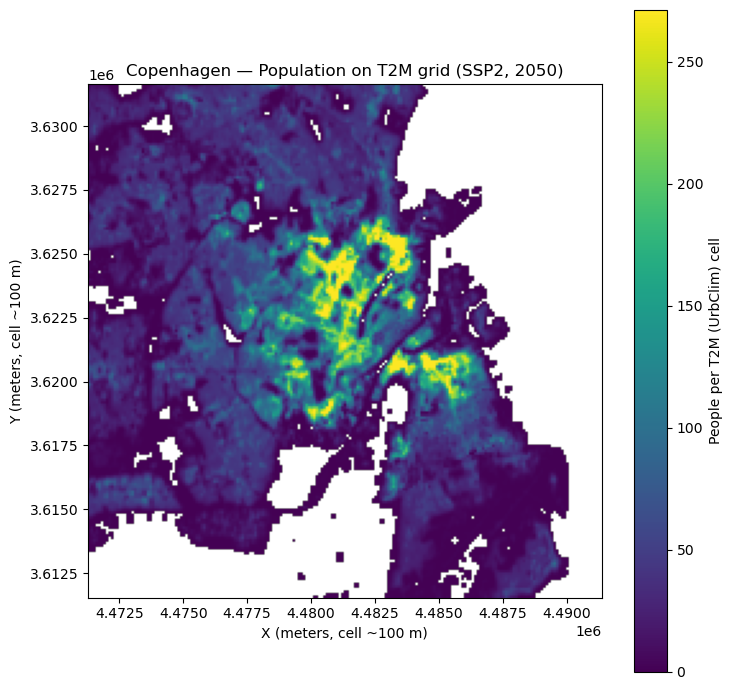

In [22]:
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds
import numpy as np

# Visualise one population grid on the reference hazard geometry.
# Choose the scenario and year to inspect.
SCEN = "SSP2"  # or "SSP1", "SSP3", etc.
YEAR = 2050    # 2020, 2030, 2040, or 2050

# Select the appropriate total-population grid.
if YEAR == 2020:
    pop_grid = pop_on_ref
elif YEAR == 2030:
    pop_grid = pop_on_ref_2030
else:
    pop_grid = future_pop_on_ref[SCEN][YEAR]

plot_arr = np.where(CITY_MASK, pop_grid, np.nan)
h, w = plot_arr.shape
left, bottom, right, top = array_bounds(h, w, ref_meta["transform"])
vmax = np.nanpercentile(plot_arr, 99)
origin = "upper" if ref_meta["transform"].e < 0 else "lower"

plt.figure(figsize=(7.5, 7))
im = plt.imshow(
    plot_arr,
    extent=(left, right, bottom, top),
    origin=origin,
    vmax=vmax,
)
cb = plt.colorbar(im)
cb.set_label("People per T2M (UrbClim) cell")
plt.title(f"{CITY} — Population on T2M grid ({SCEN}, {YEAR})")
plt.xlabel(f"X (meters, cell ~{dx:.0f} m)")
plt.ylabel(f"Y (meters, cell ~{dy:.0f} m)")
plt.gca().set_aspect("equal", "box")
plt.tight_layout()
plt.show()


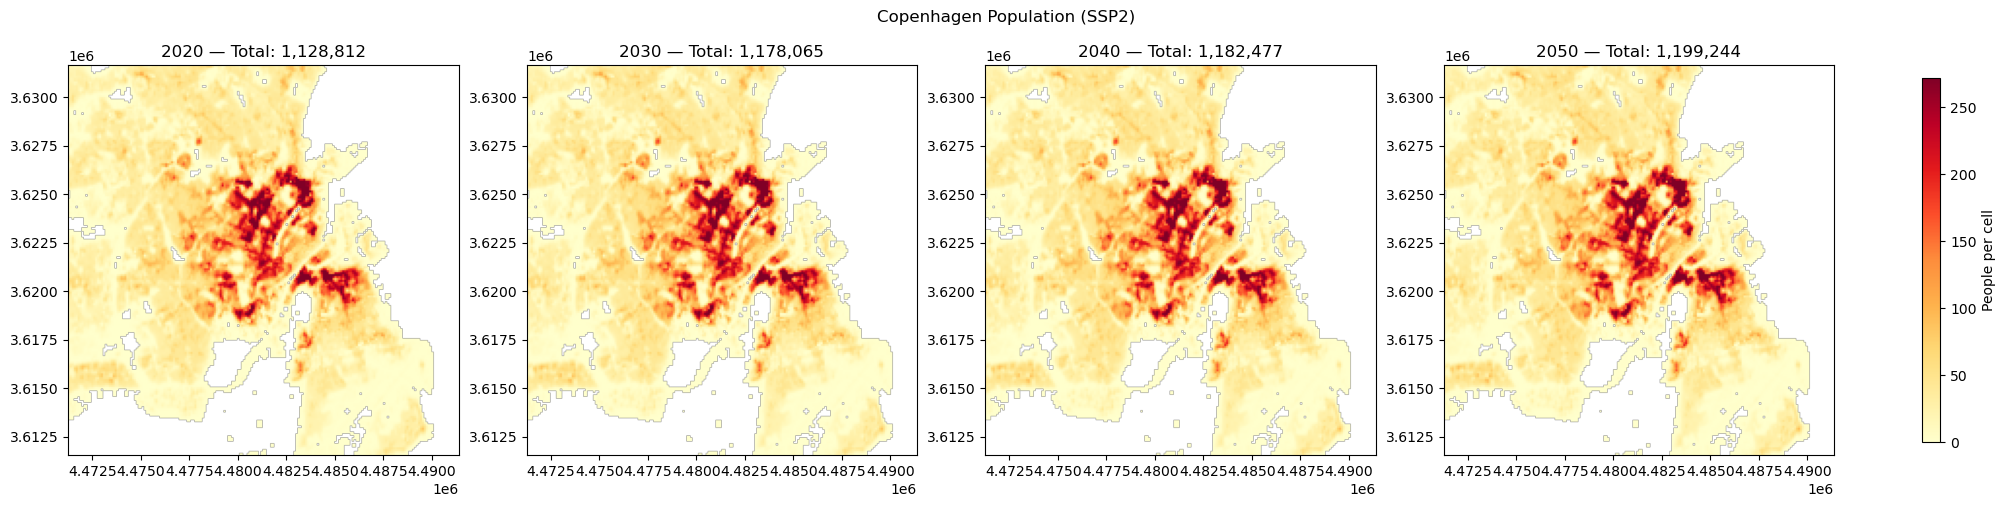

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
SCEN = "SSP2"

years = [2020, 2030, 2040, 2050]

for ax, year in zip(axes, years):
    if year == 2020:
        pop_grid = pop_on_ref
    elif year == 2030:
        pop_grid = pop_on_ref_2030
    else:
        pop_grid = future_pop_on_ref[SCEN][year]

    plot_arr = np.where(CITY_MASK, pop_grid, np.nan)
    total = np.nansum(plot_arr)

    im = ax.imshow(
        plot_arr, extent=(left, right, bottom, top),
        origin=origin, vmax=vmax, cmap="YlOrRd"
    )
    ax.set_title(f"{year} — Total: {total:,.0f}")
    ax.set_aspect("equal")

fig.suptitle(f"{CITY} Population ({SCEN})")
fig.colorbar(im, ax=axes, shrink=0.8, label="People per cell")
plt.show()

## Vulnerability Layer on the Same Grid

The notebook then constructs the vulnerability layer on the same reference grid used for hazard and exposure. This step is delegated to `cityheat/vulnerability_layer.py`, which resolves the city-specific source layers from the config and returns harmonised component rasters plus the composite Social Vulnerability Index (SVI).


Loaded projected 2020 vulnerability baseline. SVI mean=0.594, std=0.217


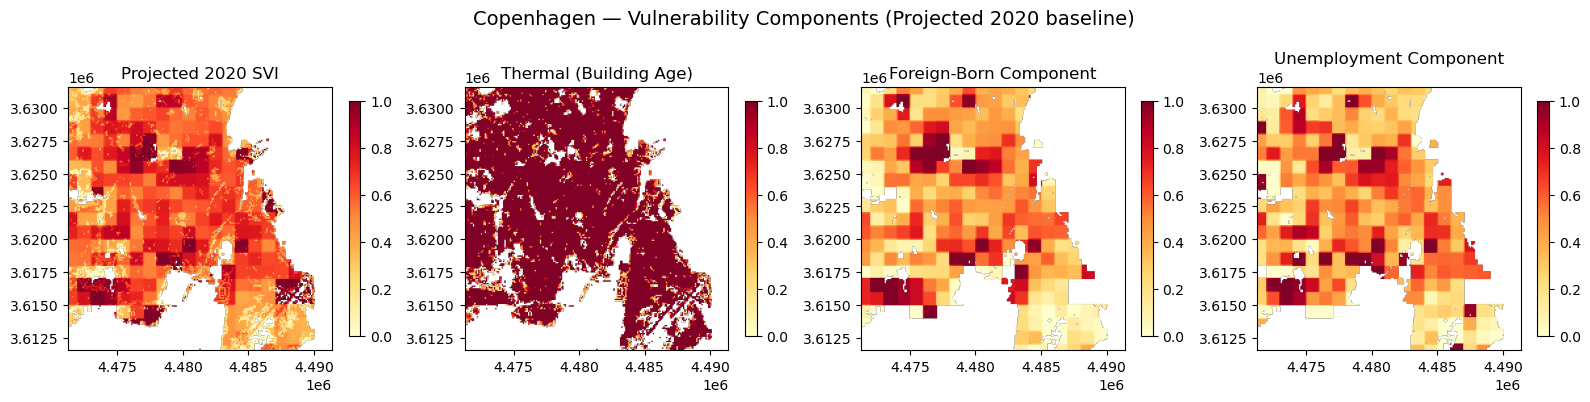

In [24]:
# Show the projected 2020 vulnerability baseline if it already exists.
# Otherwise fall back to the legacy baseline bundle that NB03 later uses
# to derive projected vulnerability layers.
from cityheat.vulnerability_layer import build_vulnerability_layer, load_vulnerability
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

vuln_cfg = cfg.get("vulnerability", {})
if vuln_cfg.get("enabled", True):
    try:
        vuln = load_vulnerability(INT, SLUG, year=2020)
        titles = [
            "Projected 2020 SVI",
            "Thermal (Building Age)",
            "Foreign-Born Component",
            "Unemployment Component",
        ]
        suptitle = f"{CITY} — Vulnerability Components (Projected 2020 baseline)"
        print(
            f"Loaded projected 2020 vulnerability baseline. "
            f"SVI mean={np.nanmean(vuln['svi']):.3f}, std={np.nanstd(vuln['svi']):.3f}"
        )
    except FileNotFoundError:
        vuln = build_vulnerability_layer(
            cfg,
            ref_meta,
            CITY_MASK,
            fua,
            int_dir=INT,
            base_path=BASE,
            verbose=False,
        )
        titles = [
            "Legacy baseline SVI",
            "Thermal (Building Age)",
            "Foreign-Born Component (rank-based)",
            "Unemployment Component (rank-based)",
        ]
        suptitle = f"{CITY} — Vulnerability Components (Legacy baseline bundle)"
        print(
            "Projected 2020 vulnerability baseline not found yet. "
            "Built the legacy baseline bundle used to derive projected layers in NB03."
        )
        print(
            f"Legacy baseline SVI mean={np.nanmean(vuln['svi']):.3f}, "
            f"std={np.nanstd(vuln['svi']):.3f}"
        )

    # Quick diagnostic maps of the composite SVI and its components.
    h, w = vuln["svi"].shape
    left, bottom, right, top = array_bounds(h, w, ref_meta["transform"])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    arrays = [vuln["svi"], vuln["thermal"], vuln["foreign"], vuln["unemp"]]

    for ax, title, arr in zip(axes, titles, arrays):
        plot_arr = np.where(CITY_MASK, arr, np.nan)
        im = ax.imshow(
            plot_arr,
            extent=(left, right, bottom, top),
            origin="upper",
            cmap="YlOrRd",
            vmin=0,
            vmax=1,
        )
        ax.set_title(title)
        ax.set_aspect("equal")
        plt.colorbar(im, ax=ax, shrink=0.7)

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Vulnerability layer disabled in config")


The maps below are diagnostic rather than final figures. Their purpose is to confirm spatial coverage, plausible gradients, and correct alignment with the common analysis grid before the vulnerability outputs are used downstream.


The following correlations are also diagnostic rather than calibration steps. They help interpret how the component layers co-vary with one another and with the composite SVI, and they are useful for spotting unexpected behaviour in the configured inputs.


In [25]:
import numpy as np
import pandas as pd

# Correlation diagnostics for the transformed vulnerability components and the final SVI.
components = {
    "thermal": vuln["thermal"],
    "foreign": vuln["foreign"],
    "unemp":   vuln["unemp"],
    "svi":     vuln["svi"],
}

# Keep only pixels inside the analysis mask where every component is defined.
mask = CITY_MASK.copy()
for arr in components.values():
    mask &= np.isfinite(arr)

flat = {name: arr[mask].ravel() for name, arr in components.items()}
df = pd.DataFrame(flat)

# Pearson for linear association; Spearman for monotonic association.
corr_pearson  = df.corr(method="pearson")
corr_spearman = df.corr(method="spearman")

print("Pearson correlations:\n", corr_pearson)
print("\nSpearman correlations:\n", corr_spearman)


Pearson correlations:
           thermal   foreign     unemp       svi
thermal  1.000000  0.037137  0.027934  0.447523
foreign  0.037137  1.000000  0.651569  0.829979
unemp    0.027934  0.651569  1.000000  0.823387
svi      0.447523  0.829979  0.823387  1.000000

Spearman correlations:
           thermal   foreign     unemp       svi
thermal  1.000000  0.056413  0.042033  0.352174
foreign  0.056413  1.000000  0.661195  0.849430
unemp    0.042033  0.661195  1.000000  0.842354
svi      0.352174  0.849430  0.842354  1.000000


The exact correlation pattern is city-specific and depends on the configured source data. What matters here is that the components vary sensibly on the common grid and that the final index is not being driven by obviously broken or misaligned inputs.


In [26]:
# Compare raw census-derived rates/shares with the transformed vulnerability components.
import numpy as np
import pandas as pd

from cityheat.vulnerability_layer import (
    get_vuln_config,
    resolve_path,
    reproject_to_ref,
)

vuln_cfg = get_vuln_config(cfg)
census_nodata = vuln_cfg.get("census_nodata", -9999)

# Raw foreign-born share on the reference grid.

pop_path = resolve_path(cfg, vuln_cfg["files"]["census_pop"], base_path=BASE)
oth_path = resolve_path(cfg, vuln_cfg["files"]["census_oth"], base_path=BASE)

pop_total = reproject_to_ref(
    pop_path, ref_meta,
    resampling="sum",
    src_nodata=census_nodata
)
pop_oth   = reproject_to_ref(
    oth_path, ref_meta,
    resampling="sum",
    src_nodata=census_nodata
)

valid_foreign = (
    (pop_total > 0) &
    np.isfinite(pop_total) &
    np.isfinite(pop_oth) &
    CITY_MASK
)

foreign_share_raw = np.full_like(pop_total, np.nan, dtype=np.float32)
foreign_share_raw[valid_foreign] = np.clip(
    pop_oth[valid_foreign] / pop_total[valid_foreign],
    0, 1
)

# Raw non-employment rate used as the unemployment proxy.

wa_path  = resolve_path(cfg, vuln_cfg["files"]["census_working_age"], base_path=BASE)
emp_path = resolve_path(cfg, vuln_cfg["files"]["census_emp"],          base_path=BASE)

working_age = reproject_to_ref(
    wa_path,  ref_meta,
    resampling="sum",
    src_nodata=census_nodata
)
pop_emp     = reproject_to_ref(
    emp_path, ref_meta,
    resampling="sum",
    src_nodata=census_nodata
)

valid_unemp = (
    (working_age > 0) &
    np.isfinite(working_age) &
    np.isfinite(pop_emp) &
    CITY_MASK
)

emp_rate_raw = np.full_like(working_age, np.nan, dtype=np.float32)
emp_rate_raw[valid_unemp] = np.clip(
    pop_emp[valid_unemp] / working_age[valid_unemp],
    0, 1
)

nonemp_rate_raw = 1.0 - emp_rate_raw  # raw unemployment-proxy rate

# Build a comparison table between raw rates/shares and transformed vulnerability components.

thermal_vuln = vuln["thermal"]   # already linear transform of GHS age
foreign_vuln = vuln["foreign"]   # percentile version
unemp_vuln   = vuln["unemp"]     # percentile version

mask = CITY_MASK & np.isfinite(foreign_share_raw) & np.isfinite(nonemp_rate_raw)

df_raw = pd.DataFrame({
    "foreign_share_raw": foreign_share_raw[mask].ravel(),
    "nonemp_rate_raw":   nonemp_rate_raw[mask].ravel(),
    "thermal_vuln":      thermal_vuln[mask].ravel(),
    "foreign_vuln":      foreign_vuln[mask].ravel(),
    "unemp_vuln":        unemp_vuln[mask].ravel(),
})

corr_pearson_raw  = df_raw.corr(method="pearson")
corr_spearman_raw = df_raw.corr(method="spearman")

print("Pearson (raw shares + vuln vars):\n", corr_pearson_raw)
print("\nSpearman (raw shares + vuln vars):\n", corr_spearman_raw)


Pearson (raw shares + vuln vars):
                    foreign_share_raw  nonemp_rate_raw  thermal_vuln  \
foreign_share_raw           1.000000         0.405947      0.016717   
nonemp_rate_raw             0.405947         1.000000      0.001347   
thermal_vuln                0.016717         0.001347      1.000000   
foreign_vuln                0.955809         0.442746      0.037137   
unemp_vuln                  0.600824         0.871092      0.027934   

                   foreign_vuln  unemp_vuln  
foreign_share_raw      0.955809    0.600824  
nonemp_rate_raw        0.442746    0.871092  
thermal_vuln           0.037137    0.027934  
foreign_vuln           1.000000    0.645015  
unemp_vuln             0.645015    1.000000  

Spearman (raw shares + vuln vars):
                    foreign_share_raw  nonemp_rate_raw  thermal_vuln  \
foreign_share_raw           1.000000         0.650446      0.055670   
nonemp_rate_raw             0.650446         1.000000      0.041197   
thermal_vuln

## Saving Harmonised Assets

Finally, the notebook writes the common spatial metadata and the harmonised hazard, exposure, and mask products needed downstream. These outputs are the bridge between the raw inputs handled in NB01 and the CLIMADA-ready objects created in NB03.


In [27]:
import json, numpy as np, rasterio as rio
from rasterio.crs import CRS

# Persist the reference grid, masks, manifests, and harmonised exposure products.
epsg = ref_meta["crs"].to_epsg()
ref_meta_slim = {
    "crs_epsg": int(epsg) if epsg is not None else None,
    "crs_wkt": ref_meta["crs"].to_wkt(),
    "transform": list(ref_meta["transform"]),
    "width": int(ref_meta["width"]),
    "height": int(ref_meta["height"]),
}
INT.mkdir(parents=True, exist_ok=True)

with open(INT / "ref_meta.json", "w") as f:
    json.dump(ref_meta_slim, f, indent=2)

tmpl_path = INT / "template_ref.tif"
profile = {**ref_meta, "dtype": "float32", "count": 1, "nodata": np.float32(np.nan)}
with rio.open(tmpl_path, "w", **profile) as dst:
    dst.write(np.full((ref_meta["height"], ref_meta["width"]), np.nan, dtype="float32"), 1)

np.savez_compressed(INT / "city_mask.npz", city_mask=CITY_MASK.astype(np.uint8))
with rio.open(INT / "city_mask.tif", "w", **{**profile, "dtype": "uint8", "nodata": 0}) as dst:
    dst.write(CITY_MASK.astype("uint8"), 1)

fua_out = OUT / f"{SLUG}_fua.gpkg"
fua.to_file(fua_out, layer="fua", driver="GPKG")

# Hazard manifest for the daily-mean T2M files masked to the FUA.
wanted_years = clim_cfg.get("years", cfg.get("ac", {}).get("years", [2020, 2030, 2040, 2050]))
wanted_years = list(map(int, wanted_years))

def _slugify_part(x) -> str:
    return "".join(ch.lower() if ch.isalnum() else "-" for ch in str(x).strip()).strip("-")

t2m_run_tag = globals().get(
    "T2M_RUN_TAG",
    (
        f"bm-{_slugify_part(T2M_BASELINE_MODE)}"
        f"__sc-{_slugify_part(T2M_SCEN)}"
        f"__pb-{_slugify_part(T2M_PCT_BAND if 'T2M_PCT_BAND' in globals() else 'central')}"
    ),
)

t2m_nc_paths = {
    y: str(OUTP(f"hazard/T2M_daily_mean_{y}_FUA_degC__{t2m_run_tag}.nc"))
    for y in wanted_years
}
t2m_nc_paths_legacy = {
    y: str(OUTP(f"hazard/T2M_daily_mean_{y}_FUA_degC.nc"))
    for y in wanted_years
}

haz_manifest = {
    "slug": SLUG,
    "hazard_type": "t2m_daily_mean",
    "units": "degC",
    "run_tag": t2m_run_tag,
    "baseline_mode": T2M_BASELINE_MODE,
    "baseline_description": baseline_meta.get("baseline_label") if "baseline_meta" in globals() else None,
    "baseline_peak_day": baseline_meta.get("extreme_peak_day") if "baseline_meta" in globals() else None,
    "baseline_peak_year": baseline_meta.get("extreme_peak_year") if "baseline_meta" in globals() else None,
    "delta_pct_band": T2M_PCT_BAND if "T2M_PCT_BAND" in globals() else "central",
    "grid_crs_epsg": int(epsg) if epsg is not None else None,
    "variable_name": "T2M",
    "files": {str(y): p for y, p in t2m_nc_paths.items()},
    "files_legacy": {str(y): p for y, p in t2m_nc_paths_legacy.items()},
}

haz_manifest_latest = INT / "hazard_manifest.json"
haz_manifest_tagged = INT / f"hazard_manifest__{t2m_run_tag}.json"

with open(haz_manifest_latest, "w") as f:
    json.dump(haz_manifest, f, indent=2)
with open(haz_manifest_tagged, "w") as f:
    json.dump(haz_manifest, f, indent=2)

# Save the direct WorldPop years explicitly.

# 2020 direct WorldPop
np.savez_compressed(
    INT / f"age_on_ref_{SLUG}_2020.npz",
    lt15   = age_on_ref["<15"].astype("float32"),
    a15_64 = age_on_ref["15-64"].astype("float32"),
    g65    = age_on_ref["65+"].astype("float32"),
)
np.savez_compressed(
    INT / f"pop_on_ref_{SLUG}_2020.npz",
    pop = pop_on_ref.astype("float32"),
)

# 2030 direct WorldPop
np.savez_compressed(
    INT / f"age_on_ref_{SLUG}_2030.npz",
    lt15   = age_on_ref_2030["<15"].astype("float32"),
    a15_64 = age_on_ref_2030["15-64"].astype("float32"),
    g65    = age_on_ref_2030["65+"].astype("float32"),
)
np.savez_compressed(
    INT / f"pop_on_ref_{SLUG}_2030.npz",
    pop = pop_on_ref_2030.astype("float32"),
)

# Scenario × year exposure manifest.
# 2020 and 2030 are direct WorldPop; 2040 and 2050 are WCDE-scaled from 2030.
expo_manifest = {
    "slug": SLUG,
    "worldpop_direct_years": [2020, 2030],
    "wcde_scale_base_year": 2030,
    "wcde_country": WP_COUNTRY,
    "wcde_iso3": WP_ISO3,
    "age_groups": ["<15", "15-64", "65+"],
    "direct_worldpop": {
        "2020": {
            "age_npz": str(INT / f"age_on_ref_{SLUG}_2020.npz"),
            "pop_npz": str(INT / f"pop_on_ref_{SLUG}_2020.npz"),
        },
        "2030": {
            "age_npz": str(INT / f"age_on_ref_{SLUG}_2030.npz"),
            "pop_npz": str(INT / f"pop_on_ref_{SLUG}_2030.npz"),
        },
    },
    "scenarios": {},
}

for s_code in scenario_labels:
    expo_manifest["scenarios"][s_code] = {}

    for year in (2040, 2050):
        ages_grids = future_age_on_ref[s_code][year]
        tot_grid   = future_pop_on_ref[s_code][year]

        age_path = INT / f"age_on_ref_{SLUG}_{s_code}_{year}.npz"
        pop_path = INT / f"pop_on_ref_{SLUG}_{s_code}_{year}.npz"

        np.savez_compressed(
            age_path,
            lt15   = ages_grids["<15"].astype("float32"),
            a15_64 = ages_grids["15-64"].astype("float32"),
            g65    = ages_grids["65+"].astype("float32"),
        )
        np.savez_compressed(
            pop_path,
            pop = tot_grid.astype("float32"),
        )

        expo_manifest["scenarios"][s_code][str(year)] = {
            "age_npz": str(age_path),
            "pop_npz": str(pop_path),
        }

with open(INT / "exposure_manifest.json", "w") as f:
    json.dump(expo_manifest, f, indent=2)

# Convenience GeoTIFFs with explicit year names.
gt_profile = {**ref_meta, "dtype": "float32", "count": 1, "nodata": np.float32(np.nan)}

# 2020
with rio.open(INT / "pop_on_ref_2020.tif", "w", **gt_profile) as dst:
    dst.write(pop_on_ref.astype("float32"), 1)
with rio.open(INT / "age_lt15_on_ref_2020.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["<15"].astype("float32"), 1)
with rio.open(INT / "age_15_64_on_ref_2020.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["15-64"].astype("float32"), 1)
with rio.open(INT / "age_65p_on_ref_2020.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["65+"].astype("float32"), 1)

# 2030
with rio.open(INT / "pop_on_ref_2030.tif", "w", **gt_profile) as dst:
    dst.write(pop_on_ref_2030.astype("float32"), 1)
with rio.open(INT / "age_lt15_on_ref_2030.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref_2030["<15"].astype("float32"), 1)
with rio.open(INT / "age_15_64_on_ref_2030.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref_2030["15-64"].astype("float32"), 1)
with rio.open(INT / "age_65p_on_ref_2030.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref_2030["65+"].astype("float32"), 1)

print("Saved:")
print("  -", INT / "ref_meta.json")
print("  -", tmpl_path)
print("  -", INT / "city_mask.npz")
print("  -", INT / "city_mask.tif")
print("  -", INT / "hazard_manifest.json")
print("  -", INT / f"hazard_manifest__{t2m_run_tag}.json")
print("  -", fua_out)
print("  -", INT / f"age_on_ref_{SLUG}_2020.npz")
print("  -", INT / f"pop_on_ref_{SLUG}_2020.npz")
print("  -", INT / f"age_on_ref_{SLUG}_2030.npz")
print("  -", INT / f"pop_on_ref_{SLUG}_2030.npz")
print("  -", INT / "exposure_manifest.json")
print("  -", INT / "pop_on_ref_2020.tif")
print("  -", INT / "pop_on_ref_2030.tif")


Saved:
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/interim/ref_meta.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/interim/template_ref.tif
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/interim/city_mask.npz
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/interim/city_mask.tif
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/interim/hazard_manifest.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/interim/hazard_manifest__bm-climatology-mean__sc-curpol__pb-central.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/copenhagen_fua.gpkg
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/copenhagen/interim/age_on_ref_copenhagen_2020.npz
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outp